# Tidy Data Project

__Ryan Williams__

## Description

This project is meant to transform a provided data set to follow the "tidy data principles" presented in Hadley Wickham's paper __*Tidy Data*__. 

The data set choosen for this project is the *Mutant MoneyBall* dataset. This dataset tracks the __comic book collectible value__ of X-Men characters across different decades (1960s–1990s). At a quick glance we can see the dataset has a lot of missing values. 

#### Step 1: Loading the dataset 

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print('Libraries loaded successfully.')
pd.set_option('display.max_columns', 20)
pd.set_option('display.max_rows', 15)
sns.set_theme(style='whitegrid', palette='muted')

path = r"C:\Users\willi\OneDrive\Documents\Elements of Computing II\Williams-Data-Science-Portfolio\Tidy_Data_Project\mutant_moneyball.csv"
# Put the path to your dataset above 

# Load the dataset
df_raw = pd.read_csv(path)

print(f'Shape: {df_raw.shape}')
print(f'\nColumns:\n{list(df_raw.columns)}')
df_raw.head()

Libraries loaded successfully.
Shape: (26, 17)

Columns:
['Member', 'TotalValue60s_heritage', 'TotalValue70s_heritage', 'TotalValue80s_heritage', 'TotalValue90s_heritage', 'TotalValue60s_ebay', 'TotalValue70s_ebay', 'TotalValue80s_ebay', 'TotalValue90s_ebay', 'TotalValue60s_wiz', 'TotalValue70s_wiz', 'TotalValue80s_wiz', 'TotalValue90s_wiz', 'TotalValue60s_oStreet', 'TotalValue70s_oStreet', 'TotalValue80s_oStreet', 'TotalValue90s_oStreet']


,Member,TotalValue60s_heritage,TotalValue70s_heritage,TotalValue80s_heritage,TotalValue90s_heritage,TotalValue60s_ebay,TotalValue70s_ebay,TotalValue80s_ebay,TotalValue90s_ebay,TotalValue60s_wiz,TotalValue70s_wiz,TotalValue80s_wiz,TotalValue90s_wiz,TotalValue60s_oStreet,TotalValue70s_oStreet,TotalValue80s_oStreet,TotalValue90s_oStreet
0,warrenWorthington,929056.0,154585.0,23957.0,960.0,23335.0,3362.0,583.0,97.0,"$7,913.00","$1,105.00",$226.00,$65.75,"$68,160.00","$7,360.00",$975.00,$123.00
1,hankMcCoy,929776.0,20705.0,6631.0,881.0,23377.0,1224.0,289.0,82.0,"$7,953.00",$851.00,$89.00,$38.50,"$68,390.00","$5,260.00",$431.00,$81.00
2,scottSummers,933616.0,188635.0,29240.0,739.0,23420.0,5431.0,1031.0,82.0,"$7,993.00","$1,979.00",$438.00,$39.25,"$68,590.00","$11,675.00","$1,427.00",$74.00
3,bobbyDrake,929776.0,154585.0,1514.0,874.0,23377.0,3362.0,70.0,93.0,"$7,953.00","$1,105.00",$48.00,$62.00,"$68,390.00","$7,360.00",$137.00,$108.00
4,jeanGrey,933616.0,179899.0,16868.0,1708.0,23420.0,4903.0,665.0,170.0,"$7,993.00","$1,679.00",$165.00,$108.00,"$68,590.00","$10,265.00",$822.00,$189.00


### Step 1: Inspect Raw Data
We begin by examining the dataset to identify:
- Our types of data (this will be important later)
- Our number of unique members to check formatting (hint: recall the shape of the data)
- Check for missing data

In [24]:
print('Data types:')
print(df_raw.dtypes)

print(f'\nNumber of characters: {df_raw["Member"].nunique()}')
print(f'Total missing values: {df_raw.isnull().sum().sum()}')

Data types:
Member                     object
TotalValue60s_heritage    float64
TotalValue70s_heritage    float64
TotalValue80s_heritage    float64
TotalValue90s_heritage    float64
                           ...   
TotalValue90s_wiz          object
TotalValue60s_oStreet      object
TotalValue70s_oStreet      object
TotalValue80s_oStreet      object
TotalValue90s_oStreet      object
Length: 17, dtype: object

Number of characters: 26
Total missing values: 132


### Step 2: Reshaping the Data (Melting)
Our dataset is currently very wide. In order to fix that we use `pd.melt()` to convert it into long format. This way:
- One column represents the variable
- One column represents the value

In [25]:
# All columns except 'Member' are value columns to be melted
value_cols = [col for col in df_raw.columns if col != 'Member']
print(f'Value columns to melt: {value_cols}')

# MELT: stack all value columns into rows
df_melted = df_raw.melt(
    id_vars=['Member'],
    value_vars=value_cols,
    var_name='variable',   # column name -> 'TotalValue60s_heritage'
    value_name='value'     # cell value  -> dollar amount
)

print(f'\nShape after melt: {df_melted.shape}')
df_melted.head(10)

Value columns to melt: ['TotalValue60s_heritage', 'TotalValue70s_heritage', 'TotalValue80s_heritage', 'TotalValue90s_heritage', 'TotalValue60s_ebay', 'TotalValue70s_ebay', 'TotalValue80s_ebay', 'TotalValue90s_ebay', 'TotalValue60s_wiz', 'TotalValue70s_wiz', 'TotalValue80s_wiz', 'TotalValue90s_wiz', 'TotalValue60s_oStreet', 'TotalValue70s_oStreet', 'TotalValue80s_oStreet', 'TotalValue90s_oStreet']

Shape after melt: (416, 3)


,Member,variable,value
0,warrenWorthington,TotalValue60s_heritage,929056.0
1,hankMcCoy,TotalValue60s_heritage,929776.0
2,scottSummers,TotalValue60s_heritage,933616.0
3,bobbyDrake,TotalValue60s_heritage,929776.0
4,jeanGrey,TotalValue60s_heritage,933616.0
5,alexSummers,TotalValue60s_heritage,34519.0
6,lornaDane,TotalValue60s_heritage,76279.0
7,ororoMunroe,TotalValue60s_heritage,NaN
8,kurtWagner,TotalValue60s_heritage,NaN
9,loganHowlett,TotalValue60s_heritage,NaN


### Step 3: Cleaning combo variables
We have a few strings that look a little chaotic, so we're going to want to reformat some of those. Starting with `TotalValueYRs_source`. The goal is to separate this combo variable into three variabls: decade, source, and value.

#### (3a) Removing the redundant "TotalValue" 
We use `.str.replace()` to remove unwanted text and standardize formatting.

In [26]:
# STR.REPLACE(): strip 'TotalValue' prefix
# e.g. 'TotalValue60s_heritage' -> '60s_heritage'
df_melted['variable'] = df_melted['variable'].str.replace('TotalValue', '', regex=False)

print('After str.replace() — unique variable values:')
print(df_melted['variable'].unique())

After str.replace() — unique variable values:
['60s_heritage' '70s_heritage' '80s_heritage' '90s_heritage' '60s_ebay'
 '70s_ebay' '80s_ebay' '90s_ebay' '60s_wiz' '70s_wiz' '80s_wiz' '90s_wiz'
 '60s_oStreet' '70s_oStreet' '80s_oStreet' '90s_oStreet']


#### (3b) Removing all $'s, commas, and white spaces so that all values are the same format. 
Here we're using `astype(str)` to treat all values as strings and then we use `str.replace()` to make the formatting changes.

In [27]:
# STR.REPLACE(): remove '$' and ',' from dollar-formatted strings
# Some values are already numeric (heritage, ebay) and some are strings (wiz, oStreet)
df_melted['value'] = (
    df_melted['value']
    .astype(str)                            # cast everything to string first
    .str.replace('$', '', regex=False)      # remove dollar sign
    .str.replace(',', '', regex=False)      # remove comma thousands separator
    .str.strip()                            # remove any leading/trailing whitespace
)

# Convert to float
df_melted['value'] = pd.to_numeric(df_melted['value'], errors='coerce')

print('Value column dtype after cleaning:', df_melted['value'].dtype)
print(f'Missing values in value column: {df_melted["value"].isnull().sum()}')
df_melted.head(8)

Value column dtype after cleaning: float64
Missing values in value column: 132


,Member,variable,value
0,warrenWorthington,60s_heritage,929056.0
1,hankMcCoy,60s_heritage,929776.0
2,scottSummers,60s_heritage,933616.0
3,bobbyDrake,60s_heritage,929776.0
4,jeanGrey,60s_heritage,933616.0
5,alexSummers,60s_heritage,34519.0
6,lornaDane,60s_heritage,76279.0
7,ororoMunroe,60s_heritage,NaN


#### (3c) Formatting the Member Column
Capitalize the first names of members and place a space after it. 

In [28]:
# STR.REPLACE() with regex: insert a space before each capital letter
# e.g. 'warrenWorthington' -> 'warren Worthington'
df_melted['Member'] = (
    df_melted['Member']
    .str.replace(r'([A-Z])', r' \1', regex=True)  # space before capitals
    .str.strip()                                    # remove leading space
    .str.title()                                    # title-case the result
)

print('Cleaned member names:')
print(df_melted['Member'].unique())

Cleaned member names:
['Warren Worthington' 'Hank Mc Coy' 'Scott Summers' 'Bobby Drake'
 'Jean Grey' 'Alex Summers' 'Lorna Dane' 'Ororo Munroe' 'Kurt Wagner'
 'Logan Howlett' 'Peter Rasputin' 'Sean Cassidy' 'Shiro Yoshida'
 'John Proudstar' 'Kitty Pryde' 'Anna Marie Le Beau' 'Rachel Summers'
 'Eric Magnus' 'Alison Blaire' 'Longshot' 'Jonathan Silvercloud'
 'Remy Le Beau' 'Jubilation Lee' 'Lucas Bishop' 'Betsy Braddock'
 'Charles Xavier']


#### (3d): Splitting Columns
After melting, the variable column contains multiple pieces of information.
We use `.str.split()` to separate it into:
- [Column A]
- [Column B]

#### Handling Missing Data

Before we can split the columns, we will need to decide what to do with our missing values.

Missing data can arise due to:
- Incomplete records
- Errors during data collection or transformation
- Parsing issues during cleaning

It is important to handle missing data because it can bias results or cause errors later in analysis.

In [29]:
# Check missing values by column
print("Missing values by column:")
print(df_melted.isnull().sum())

Missing values by column:
Member        0
variable      0
value       132
dtype: int64


We observe that missing values primarily occur in the `value` column after transformation.

Since these values could not be reliably parsed into numeric format, we choose to **drop these rows** using `dropna()`.

This approach is appropriate because:
- The missing values represent unusable data
- Imputing values would introduce artificial bias
- The remaining dataset is still sufficiently large for analysis

In [30]:
# Drop rows where value could not be parsed
df_tidy = df_melted.dropna(subset=['value']).copy()


In [31]:
# Moving on to splitting
# Split 'variable' into 'decade' and 'source'
df_tidy[['decade', 'source']] = df_tidy['variable'].str.split('_', expand=True)

# Reorder columns logically
df_tidy = df_tidy[['Member', 'decade', 'source', 'value']].reset_index(drop=True)

print(f'Final tidy dataset shape: {df_tidy.shape}')
print('Each row = one character, one decade, one price source\n')
df_tidy.head(12)

print(f'Final tidy dataset shape: {df_tidy.shape}')
print('Each row = one character, one decade, one price source\n')
df_tidy.head(12)

Final tidy dataset shape: (284, 4)
Each row = one character, one decade, one price source

Final tidy dataset shape: (284, 4)
Each row = one character, one decade, one price source



,Member,decade,source,value
0,Warren Worthington,60s,heritage,929056.0
1,Hank Mc Coy,60s,heritage,929776.0
2,Scott Summers,60s,heritage,933616.0
3,Bobby Drake,60s,heritage,929776.0
4,Jean Grey,60s,heritage,933616.0
5,Alex Summers,60s,heritage,34519.0
6,Lorna Dane,60s,heritage,76279.0
7,Sean Cassidy,60s,heritage,39200.0
8,Eric Magnus,60s,heritage,582934.0
9,Charles Xavier,60s,heritage,819537.0


## Analyzing our cleaned dataset: Summary Statistics


In [32]:
print('=== Descriptive Statistics ===')
print(df_tidy['value'].describe().round(2))

print('\n=== Average Value by Decade ===')
print(df_tidy.groupby('decade')['value'].mean().round(2).sort_index())

print('\n=== Average Value by Source ===')
print(df_tidy.groupby('source')['value'].mean().round(2).sort_values(ascending=False))

=== Descriptive Statistics ===
count       284.00
mean      34740.82
std      138593.31
min           1.00
25%         139.25
50%         878.00
75%        6609.25
max      933616.00
Name: value, dtype: float64

=== Average Value by Decade ===
decade
60s    171852.98
70s     38544.84
80s      5420.71
90s       303.38
Name: value, dtype: float64

=== Average Value by Source ===
source
heritage    126470.58
oStreet       8166.52
ebay          3228.68
wiz           1097.49
Name: value, dtype: float64


#### First impressions
1. The distribution of values is highly right-skewed, as indicated by the large gap between the mean (34,740) and median (878). This suggests that a small number of extremely high-value observations are driving the average upward, while most observations are relatively low in value.The presence of a maximum value of 933,616 further confirms the existence of significant outliers.

4. There is a substantial difference in average values across sources. Heritage auctions have significantly higher average values compared to other platforms, suggesting that they specialize in higher-end or more collectible items.

6. In contrast, platforms such as eBay and Wiz appear to reflect more common, lower-value items. This indicates that the source of the data plays an important role in shaping observed value distributions.

8. Average values decline sharply across decades, with items from the 1960s having significantly higher average values than more recent decades. This pattern suggests that older items tend to be more valuable, possibly due to increased rarity and collector demand.

## Visualizing Data 

#### Aggregation / Pivot Table

To summarize the cleaned data, we compute the aggregation funtion (`aggfunc`) grouped any choosen ()`index`).

This helps identify patterns such as:
- [Insight]

In [ ]:

pivot = df_tidy.pivot_table(
    values='value',    # replace as needed 
    index='Member',    # replace as needed
    columns='decade',  # replace as needed
    aggfunc='mean'     # replace as needed 
).round(2)

# Sort by 60s value descending
pivot = pivot.sort_values('60s', ascending=False)

print('Average collectible value per character per decade (all sources averaged):')
pivot

Average collectible value per character per decade (all sources averaged):


decade,60s,70s,80s,90s
Member,,,,
Scott Summers,258404.75,51930.00,8034.00,233.56
Jean Grey,258404.75,49186.50,4630.00,543.75
Hank Mc Coy,257374.00,7010.00,1860.00,270.62
Bobby Drake,257374.00,41603.00,442.25,284.25
Warren Worthington,257116.00,41603.00,6435.25,311.44
...,...,...,...,...
Ororo Munroe,NaN,45878.25,14814.25,737.00
Peter Rasputin,NaN,45878.25,14334.50,332.00
Rachel Summers,NaN,NaN,4254.00,136.00


The pivot table contains NaN values, which occur when there are no observations for a given combination of decade and source.

For example, certain platforms may not have listings for older decades, resulting in missing entries or `NaN`

#### Exploring Distributions 1: Distribution of Comic Values (Log Scale Histogram)

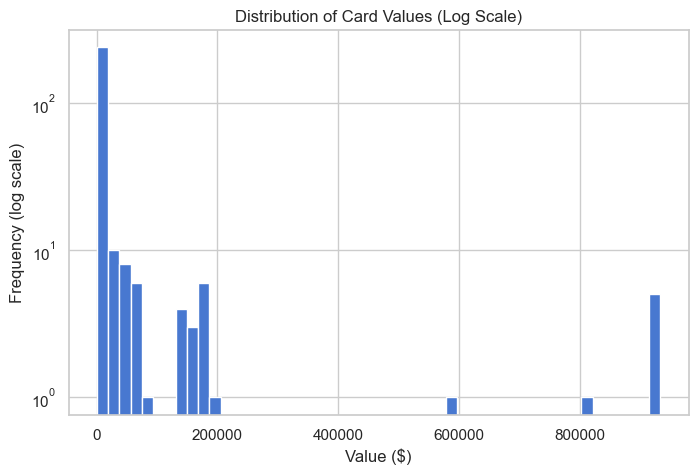

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df_tidy['value'], bins=50)
plt.yscale('log')
plt.title("Distribution of ComicValues (Log Scale)")
plt.xlabel("Value ($)")
plt.ylabel("Frequency (log scale)")
plt.show()

The distribution of comic values is highly right-skewed, with the majority of observations concentrated at lower values and a small number of extreme outliers.

The long right tail indicates that a few rare comics account for a disproportionate share of total value. 

A log scale is used to better visualize this spread, as the raw scale would obscure variation among lower-value observations.

#### Exploring Distributions 2: Comic Value Distribution by Decade (Box-plot)

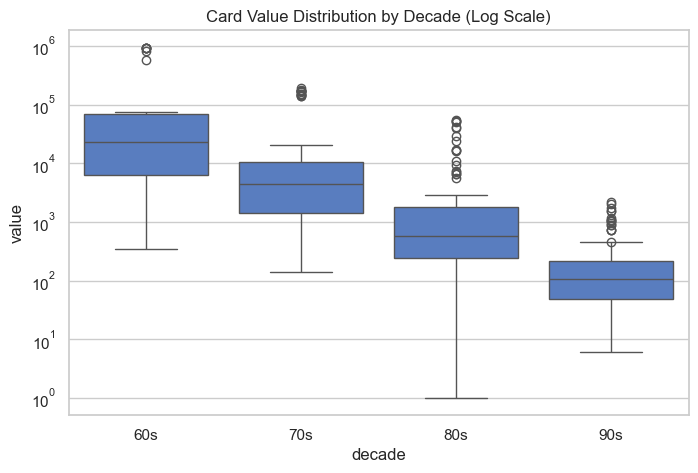

In [ ]:
import seaborn as sns

plt.figure(figsize=(8,5))
sns.boxplot(x='decade', y='value', data=df_tidy)
plt.yscale('log')
plt.title("Comic Value Distribution by Decade (Log Scale)")
plt.show()

The boxplot reveals a clear downward trend in comic values across decades, with older comic (1960s and 1970s) exhibiting higher median values and greater variability.

This suggests that older comic are generally more valuable, likely due to increased rarity and collector demand as we mentioned earlier.

Additionally, high-value outliers are concentrated in earlier decades, indicating that the most valuable comic tend to originate from older time periods.

The use of a log scale allows for meaningful comparison across decades despite the presence of extreme values.

#### Quick and fun visualization: Top 10 most valuable characters 

In [34]:
total_value = (
    df_tidy
    .groupby('Member')
    .agg(
        total_value=('value', 'sum'),
        avg_value=('value', 'mean'),
        max_value=('value', 'max')
    )
    .sort_values('total_value', ascending=False)
    .reset_index()
)

print('Top 10 most valuable X-Men characters (all decades + sources combined):')
total_value.head(10)

Top 10 most valuable X-Men characters (all decades + sources combined):


,Member,total_value,avg_value,max_value
0,Scott Summers,1274409.25,79650.578125,933616.0
1,Jean Grey,1251060.00,78191.250000,933616.0
2,Warren Worthington,1221862.75,76366.421875,929056.0
3,Bobby Drake,1198814.00,74925.875000,929776.0
4,Charles Xavier,1139010.00,71188.125000,819537.0
5,Hank Mc Coy,1066058.50,66628.656250,929776.0
6,Eric Magnus,671106.00,41944.125000,582934.0
7,Ororo Munroe,245718.00,20476.500000,171050.0
8,Logan Howlett,242333.00,20194.416667,171050.0
9,Peter Rasputin,242179.00,20181.583333,171050.0


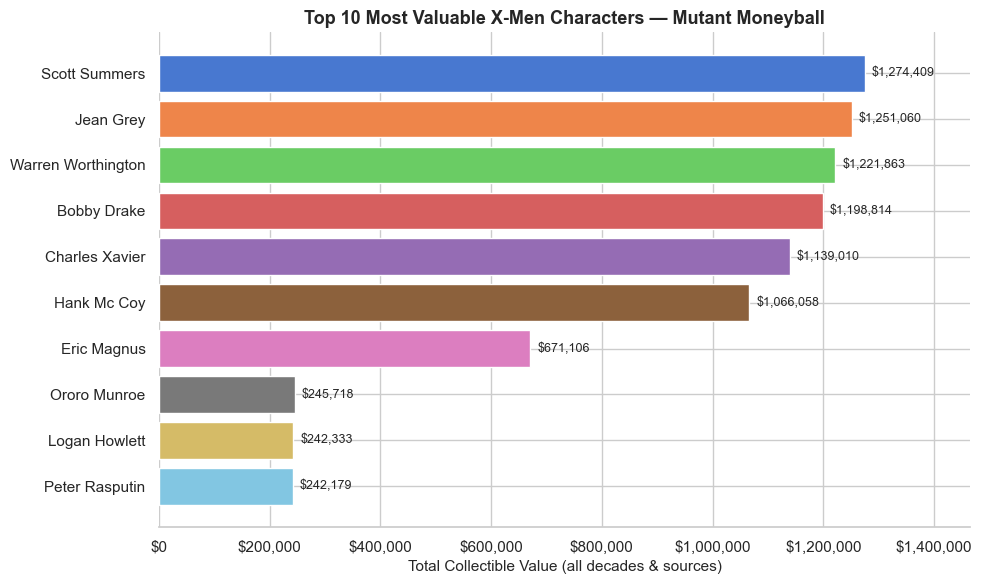

In [35]:
top10 = total_value.head(10)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    top10['Member'],
    top10['total_value'],
    color=sns.color_palette('muted', 10)
)

# Value labels
for bar in bars:
    ax.text(
        bar.get_width() + top10['total_value'].max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'${bar.get_width():,.0f}',
        va='center', fontsize=9
    )

ax.invert_yaxis()
ax.set_xlabel('Total Collectible Value (all decades & sources)', fontsize=11)
ax.set_title('Top 10 Most Valuable X-Men Characters — Mutant Moneyball', fontsize=13, fontweight='bold')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_xlim(0, top10['total_value'].max() * 1.15)
sns.despine(left=True)
plt.tight_layout()
plt.savefig('viz1_top_characters.png', dpi=150, bbox_inches='tight')
plt.show()

### References 

__Tidyr__: https://tidyr.tidyverse.org/articles/tidy-data.html 

__Data Clening Cheat Sheet__: https://www.kdnuggets.com/publications/sheets/Data_Cleaning_with_Python_Cheat_Sheet_Anello.pdf


__Tidy Data by Hadley Wickham__: https://www.jstatsoft.org/article/view/v059i10/ 
